# Notebook 01: Data Exploration & Quality Audit
The goal of this notebook is to perform a high-fidelity audit of the Bronze layer, validate the success of the Playwright scraper, and prototype the core logic for the Silver layer—specifically focusing on automated StatCan transformations and the LLM-driven mapping of job titles to National Occupational Classifications (NOC).

## Section 0: Setup

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('../src')))

The use of `sys.path.append` ensures the notebook can utilize the `src` package for transformation logic and Ollama configurations.

In [2]:
from transforms.role_mapper import map_roles
from transforms.skills_extractor import extract_tech_skills
from transforms.skills_section_extractor import extract_skills_section
from transforms.silver_transform import (
    transform_graduates,
    transform_wages_trends,
    transform_census_income,
    transform_labour_trends,
    transform_census_labour,
    transform_job_roles
)

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.interpolate import make_interp_spline, UnivariateSpline

In [4]:
import duckdb
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [5]:
from bs4 import BeautifulSoup

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
DB_PATH = "../data/warehouse.duckdb"

## Section 1: Connection and Schema Overview
Establish a connection to the DuckDB warehouse and verify that all expected tables were successfully ingested.

In [8]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT schema_name, table_name, estimated_size
        FROM duckdb_tables()
        WHERE schema_name = 'bronze';
    """).df())

  schema_name               table_name  estimated_size
0      bronze     job_descriptions_raw            6444
1      bronze         job_postings_raw            7795
2      bronze     sc_census_income_raw              44
3      bronze     sc_census_labour_raw             129
4      bronze  sc_graduates_trends_raw              84
5      bronze     sc_labour_trends_raw              48
6      bronze      sc_wages_trends_raw              16


The row counts confirm that all six tables (5 StatCan, 1 Adzuna) were successfully populated, providing a complete raw dataset for audit.

## Section 2: NOC Alignment & Taxonomy Consolidation
The [2021 National Occupational Classification (NOC)](https://noc.esdc.gc.ca/Structure/Hierarchy) provides a granular breakdown of technical roles. To optimize our SkillPath-Engine, we would map our scraped titles to the following core units:
- **21210 (Math & Stats):** Develops and applies mathematical or statistical techniques to solve complex problems and assess financial risk.
- **21211 (Data Science):** Uses advanced analytics, machine learning, and predictive modeling to extract insights from unstructured data.
- **21220 (Cybersecurity):** Plans and implements security measures to protect networks, devices, and organizational information.
- **21221 (Business Systems):** Translates corporate strategic objectives into technical IT architectures and tasks.
- **21222 (Information Systems):** Analyzes and assesses system requirements while implementing information development plans and policies.
- **21223 (Database & Data Admin):** Designs, develops, and administers data management solutions and administration standards.
- **21230 (Systems Programming):** Writes and tests code for software applications, operating systems, and communications software.
- **21231 (Software Engineering):** Researches and designs technical environments, embedded software, and information warehouses.
- **21232 (Software Development):** Designs and writes code for new systems to ensure overall efficiency and effectiveness.
- **21233 (Web Design):** Develops the visual layout, presentation, and user-interface functionality of websites.
- **21234 (Web Development):** Uses programming languages to create, modify, and integrate website capacity and performance.

## Section 3: StatCan Bronze Profiling & Silver Prototyping
In this phase, we validate the `statcan_silver_factory` logic to ensure raw StatCan datasets are correctly pivoted and standardized for downstream joins.

The transformation process includes:
- **Schema Standardization:** Leveraging the "Silver Factory" to drop redundant constant columns and map generic `VALUE` fields to descriptive aliases, ensuring the data is both human-readable and analytics-ready.
- **Dimensional Pivoting:** Prototyping the pivot transformation to flatten time-series data and categorical dimensions into a structured, single-row format per NOC code.

### 3.1. Transformation: Census Income 2021

In [9]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_census_income_raw);
    """).df())

                                          column_name column_type  NULL
0                                           Geography     VARCHAR  <NA>
1                                          Gender (3)     VARCHAR  <NA>
2                                             Age (4)     VARCHAR  <NA>
3         Highest certificate, diploma or degree (16)     VARCHAR  <NA>
4   Major field of study - Classification of Instr...     VARCHAR  <NA>
5        Work activity during the reference year (4A)     VARCHAR  <NA>
6   Occupation - Unit group - National Occupationa...     VARCHAR  <NA>
7                    Employment income statistics (7)     VARCHAR  <NA>
8                                            REF_DATE     VARCHAR  <NA>
9                                               VALUE      DOUBLE  <NA>
10                                                pid     VARCHAR  <NA>
11                                        ingested_at   TIMESTAMP  <NA>
12                                             source     VARCHA

In [10]:
census_income = transform_census_income()
census_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   education_level  44 non-null     object        
 1   occupation       44 non-null     object        
 2   median_income    42 non-null     float64       
 3   ingested_at      44 non-null     datetime64[us]
 4   source           44 non-null     object        
 5   noc_code         44 non-null     object        
dtypes: datetime64[us](1), float64(1), object(4)
memory usage: 2.2+ KB


### 3.2. Transformation: Annual Wages

In [11]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_wages_trends_raw);
    """).df())

                                   column_name column_type  NULL
0                                    Geography     VARCHAR  <NA>
1                                        Wages     VARCHAR  <NA>
2                                 Type of work     VARCHAR  <NA>
3   National Occupational Classification (NOC)     VARCHAR  <NA>
4                                       Gender     VARCHAR  <NA>
5                                    Age group     VARCHAR  <NA>
6                                     REF_DATE     VARCHAR  <NA>
7                                        VALUE      DOUBLE  <NA>
8                                          pid     VARCHAR  <NA>
9                                  ingested_at   TIMESTAMP  <NA>
10                                      source     VARCHAR  <NA>


In [12]:
wages_trends = transform_wages_trends()
wages_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   occupation    16 non-null     object        
 1   date          16 non-null     datetime64[ns]
 2   weekly_wages  16 non-null     float64       
 3   ingested_at   16 non-null     datetime64[us]
 4   source        16 non-null     object        
 5   noc_code      16 non-null     object        
dtypes: datetime64[ns](1), datetime64[us](1), float64(1), object(3)
memory usage: 896.0+ bytes


### 3.3. Transformation: Census Labour Force Status 2021

In [13]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_census_labour_raw);
    """).df())

                                          column_name column_type  NULL
0                                           Geography     VARCHAR  <NA>
1         Highest certificate, diploma or degree (16)     VARCHAR  <NA>
2                                           Age (15A)     VARCHAR  <NA>
3                                          Gender (3)     VARCHAR  <NA>
4   Occupation - Unit group - National Occupationa...     VARCHAR  <NA>
5                             Labour force status (3)     VARCHAR  <NA>
6                                            REF_DATE     VARCHAR  <NA>
7                                               VALUE      DOUBLE  <NA>
8                                                 pid     VARCHAR  <NA>
9                                         ingested_at   TIMESTAMP  <NA>
10                                             source     VARCHAR  <NA>


In [14]:
census_labour = transform_census_labour()
census_labour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   education_level  44 non-null     object        
 1   occupation       44 non-null     object        
 2   ingested_at      44 non-null     datetime64[us]
 3   source           44 non-null     object        
 4   employed         44 non-null     float64       
 5   unemployed       41 non-null     float64       
 6   noc_code         44 non-null     object        
 7   labour_force     41 non-null     float64       
dtypes: datetime64[us](1), float64(3), object(4)
memory usage: 2.9+ KB


### 3.4. Transformation: Annual Labour Force Status

In [15]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_labour_trends_raw);
    """).df())

                                  column_name column_type  NULL
0                                   Geography     VARCHAR  <NA>
1                Labour force characteristics     VARCHAR  <NA>
2  National Occupational Classification (NOC)     VARCHAR  <NA>
3                                      Gender     VARCHAR  <NA>
4                                    REF_DATE     VARCHAR  <NA>
5                                       VALUE      DOUBLE  <NA>
6                                         pid     VARCHAR  <NA>
7                                 ingested_at   TIMESTAMP  <NA>
8                                      source     VARCHAR  <NA>


In [16]:
labour_trends = transform_labour_trends()
labour_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   occupation                16 non-null     object        
 1   date                      16 non-null     datetime64[ns]
 2   ingested_at               16 non-null     datetime64[us]
 3   source                    16 non-null     object        
 4   labour force              16 non-null     float64       
 5   proportion of employment  16 non-null     float64       
 6   unemployment rate         16 non-null     float64       
 7   noc_code                  16 non-null     object        
dtypes: datetime64[ns](1), datetime64[us](1), float64(3), object(3)
memory usage: 1.1+ KB


### 3.5. Transformation: Annual Graduates

In [17]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_graduates_trends_raw);
    """).df())

                                         column_name column_type  NULL
0                                          Geography     VARCHAR  <NA>
1  International Standard Classification of Educa...     VARCHAR  <NA>
2                                     Field of study     VARCHAR  <NA>
3                                   Institution type     VARCHAR  <NA>
4                                             Gender     VARCHAR  <NA>
5                                           REF_DATE     VARCHAR  <NA>
6                                              VALUE      DOUBLE  <NA>
7                                                pid     VARCHAR  <NA>
8                                        ingested_at   TIMESTAMP  <NA>
9                                             source     VARCHAR  <NA>


In [18]:
graduates = transform_graduates()
graduates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   education_level  84 non-null     object        
 1   field_of_study   84 non-null     object        
 2   date             84 non-null     datetime64[ns]
 3   graduates        84 non-null     float64       
 4   ingested_at      84 non-null     datetime64[us]
 5   source           84 non-null     object        
 6   noc_code         84 non-null     object        
dtypes: datetime64[ns](1), datetime64[us](1), float64(1), object(4)
memory usage: 4.7+ KB


## Section 4: Job Market Distribution & Scraper Validation
Here, we measure the density of the labor market data and verify that the Playwright scraper successfully retrieved full-text job descriptions.

### 4.1. Scraper Efficiency Check

In [19]:
def extract_plain_desc(desc_html):
    if desc_html is None:
        return ""
    soup = BeautifulSoup(desc_html, 'html.parser')
    return soup.get_text(strip=True)

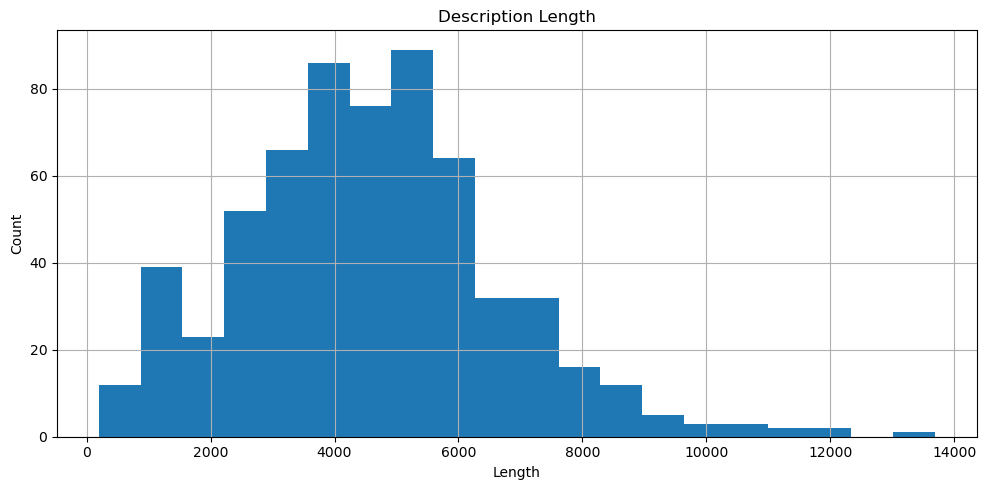

In [20]:
with duckdb.connect(DB_PATH) as con:
    (con.execute("SELECT description_html FROM bronze.job_descriptions_raw")
        .df()["description_html"]
        .apply(extract_plain_desc)
        .str.len().round(2)
        .hist(bins=20, figsize=(10,5))
    )
    plt.title("Description Length")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.tight_layout()

An average description length of 5538 characters confirms the Playwright implementation successfully bypassed Adzuna's 500-character snippet limit.

## Section 6: Semantic Role Mapping (Job Titles to NOC)
The goal here is to align varied job titles with the standardized NOC taxonomy using Sentence Transformers and optimize the mapping threshold using derivative analysis.

### 6.1. Job Postings Schema and Nulls Check

In [21]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.job_postings_raw);
    """).df())

    column_name column_type  NULL
0      job_hash     VARCHAR  <NA>
1   ingested_at   TIMESTAMP  <NA>
2        source     VARCHAR  <NA>
3   raw_payload        JSON  <NA>
4       created   TIMESTAMP  <NA>
5         title     VARCHAR  <NA>
6  redirect_url     VARCHAR  <NA>
7  search_query     VARCHAR  <NA>


In [22]:
with duckdb.connect(DB_PATH) as con:
    job_postings = con.execute("""
        SELECT
            search_query, 
            title,
            REPLACE(raw_payload->'company'->'display_name', '\"', '') as company,
            raw_payload
        FROM bronze.job_postings_raw;
    """).df()

In [23]:
job_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   search_query  695 non-null    object
 1   title         695 non-null    object
 2   company       690 non-null    object
 3   raw_payload   695 non-null    object
dtypes: object(4)
memory usage: 21.8+ KB


### 6.2. NOC Mapping (Semantic Mathcing)

In [24]:
%%time
mapped_jobs = map_roles(job_postings, yaml_path="../config/role_mapping.yaml", full_report=True)

CPU times: total: 25 s
Wall time: 4.18 s


Using semantic similarity instead of keyword matching allows the system to correctly map "Frontend Wizard" to a technical NOC code. We accomplished this using a transformer (`all-MiniLM-L6-v2`).

### 6.3. Confidence Score Distribution & Threshold Optimization

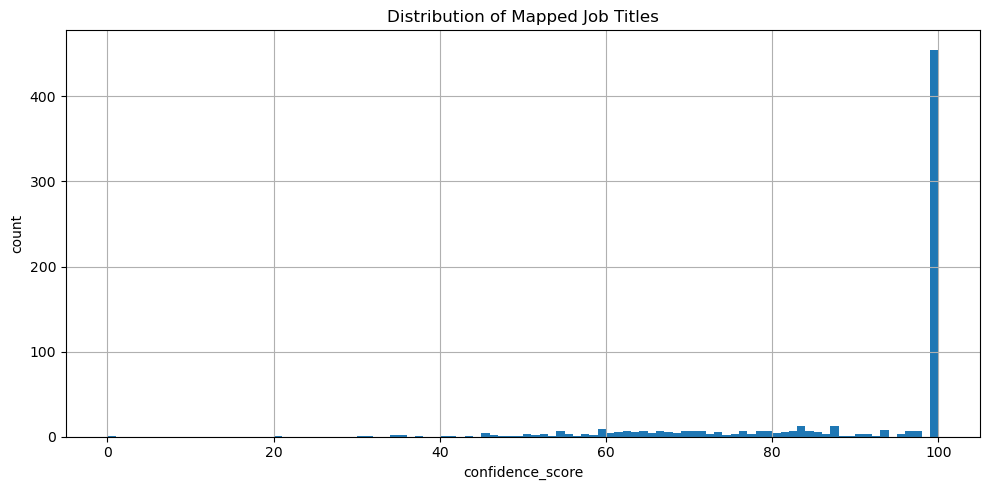

In [25]:
mapped_jobs["confidence_score"].hist(bins=100, figsize=(10,5))
plt.title("Distribution of Mapped Job Titles")
plt.xlabel("confidence_score")
plt.ylabel("count")
plt.tight_layout()

#### Finding the Optimal Threshold
We use a derivative-based approach to find the "steepest point" of data retention as a way to mathematically justify the cutoff for mapping quality.

In [26]:
thresholds = np.arange(0, 101, 1)
percentages = []
for t in thresholds:
    mask = mapped_jobs['confidence_score'] >= t
    pct = 100 * len(mapped_jobs[mask]) / len(mapped_jobs)
    percentages.append(pct)

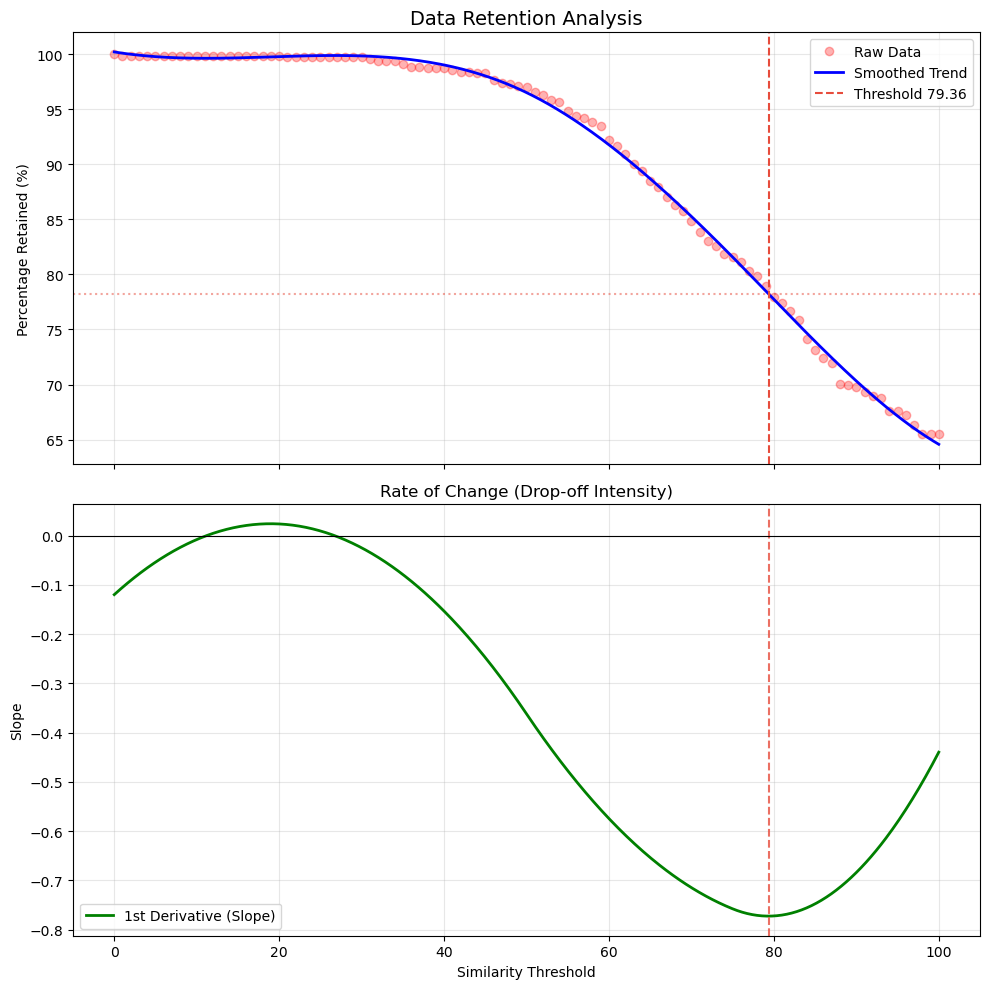

Optimal Threshold: 79.36
Data Retained at Threshold: 78.23%


In [27]:
# 1. Processing & Optimization
spline = UnivariateSpline(thresholds, percentages, s=20)
x_smooth = np.linspace(thresholds.min(), thresholds.max(), 500)
y_smooth = spline(x_smooth)
y_der = spline.derivative()(x_smooth)

# Detect the elbow (steepest descent)
steepest_idx = np.argmin(y_der)
suggested_t = np.round(x_smooth[steepest_idx], 2)
# Using the spline to find the exact Y value for consistency
retention_at_t = spline(suggested_t) 

# 2. Plotting (Vertical Stack)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Top Plot: Retention Curve
ax1.plot(thresholds, percentages, 'ro', alpha=0.3, label='Raw Data')
ax1.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Smoothed Trend')
ax1.axvline(x=suggested_t, color='#e74c3c', linestyle='--', label=f'Threshold {suggested_t}')
ax1.axhline(y=retention_at_t, color='#e74c3c', linestyle=':', alpha=0.5)
ax1.set_title('Data Retention Analysis', fontsize=14)
ax1.set_ylabel('Percentage Retained (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Plot: Derivative (Slope)
ax2.plot(x_smooth, y_der, 'g-', linewidth=2, label='1st Derivative (Slope)')
ax2.axvline(x=suggested_t, color='#e74c3c', linestyle='--', alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax2.set_title('Rate of Change (Drop-off Intensity)', fontsize=12)
ax2.set_xlabel('Similarity Threshold')
ax2.set_ylabel('Slope')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {suggested_t}")
print(f"Data Retained at Threshold: {retention_at_t:.2f}%")

### 6.4. Quality Assurance

In [28]:
(mapped_jobs[mapped_jobs["confidence_score"]
     .between(suggested_t-5, suggested_t)]
     .sample(frac=1.0, random_state=42)
     .head(20))

,title,clean_title,matched_variant,matched_role,matched_noc,confidence_score,match_method
282,Senior IT Systems Integration Developer,it systems integration developer,Systems Developer,Systems Programmer,21230,78.82,Semantic
444,Senior Research And Development Engineer,research developer engineer,Software Engineer,Software Engineer,21231,77.74,Semantic
79,AI Intern,ai,AI Developer,AI/ML Developer,21211,75.88,Semantic
657,UX/UI Design Intern (Summer 2026),ux ui design,UI/UX Designer,UI/UX Designer,21233,78.85,Semantic
319,Senior Analytics Product Specialist,analytics product specialist,Analytics Engineer,Database Engineer,21223,77.62,Semantic
292,Senior Data Quality Engineer,data quality engineer,Data Engineer,Data Engineer,21231,76.26,Semantic
340,AI Specialist,ai specialist,AI Engineer,AI/ML Developer,21211,76.58,Semantic
126,"Cloud Consultant Intern, AWS Professional Serv...",cloud consultant,Cloud Developer,Cloud Engineer,21231,79.27,Semantic
656,Web Design Student,web design,Web Designer,Web Designer,21233,76.37,Semantic
213,Salesforce Architect – Financial Services,salesforce architect,Application Architect,Technical Architect,21222,78.87,Semantic


In [29]:
for t in range(int(suggested_t)-5, 81):
    print(f"Retention @ t={t}: %{spline(t):.2f}")

Retention @ t=74: %82.33
Retention @ t=75: %81.58
Retention @ t=76: %80.81
Retention @ t=77: %80.05
Retention @ t=78: %79.28
Retention @ t=79: %78.51
Retention @ t=80: %77.73


Reviewing the 20 rows around the 74.0-79.0 threshold confirms that the semantic mapping remains accurate even at the lower bounds of the "optimal" data retention. By setting the threshold to 74, we still retain around 82% of the data.

In [30]:
optimal_t = suggested_t-5
optimal_t

74.36

### 6.5. NOC and Job Titles Density

In [31]:
conf_mask = mapped_jobs["confidence_score"] >= optimal_t

In [33]:
mapped_jobs.loc[conf_mask, "matched_noc"].value_counts(normalize=True).mul(100).round(2)

matched_noc
21232    34.45
21231    27.07
21211    17.75
21223     4.39
21222     3.87
21233     3.69
21234     3.16
21220     2.46
21230     1.76
21221     1.41
Name: proportion, dtype: float64

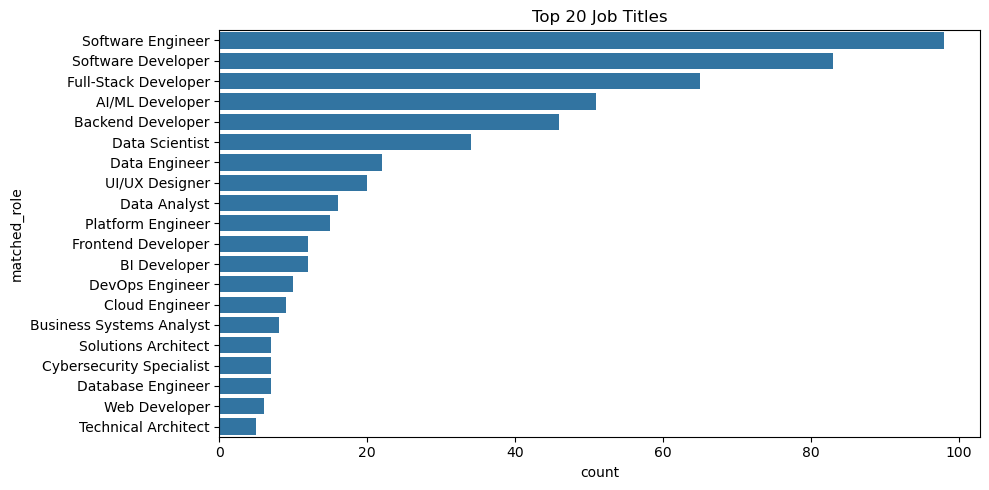

In [34]:
with duckdb.connect(DB_PATH) as con:
    job_title_dist = (
        mapped_jobs.loc[conf_mask, "matched_role"]
            .value_counts().sort_values(ascending=False)
            .to_frame()
            .reset_index(drop=False)
    )
    plt.figure(figsize=(10,5))
    sns.barplot(job_title_dist.head(20), x="count", y="matched_role")
    plt.title("Top 20 Job Titles")
    plt.tight_layout()
    plt.show()

The results show significant volume for technical roles, providing a robust statistical sample for the skill-extraction phase.

## Section 7: Knowledge Graph Feasibility (Ollama/Gemma 3)
The purpose is to demonstrate the feasibility of using local LLM inference to extract structured skills from the high-volume text retrieved in Section 3.

In [35]:
with duckdb.connect(DB_PATH) as con:
    job_descriptions = con.execute("""
        SELECT
            job_hash,
            description_html, 
            created
        FROM bronze.job_descriptions_raw
        LIMIT 100
    """).df()

### Preprocess Job Descriptions

In [50]:
sample_desc_html = job_descriptions.sample(n=1, random_state=42)['description_html'].values[0]
#print(sample_desc_html)

In [44]:
%%time
skills_sec = extract_skills_section(sample_desc_html)

CPU times: total: 0 ns
Wall time: 8 ms


In [47]:
soup = BeautifulSoup(sample_desc, "html.parser")
sample_desc = soup.get_text("\n", strip=True)

print(f"{100*(len(sample_desc) - len(skills_sec)) / len(sample_desc):.2f}% text reduction")

55.25% text reduction


In [52]:
print(skills_sec)

Build and test tools that use large language models (LLMs) to help generate website content
Work with third-party APIs to collect data for content projects
Write code to help automate content workflows and publishing tasks
Analyze internal datasets to identify common questions and patterns that can improve website content
Collaborate with our staff writers and YouTube team to design systems that maintain consistent voice and quality across generated content
Iterate quickly, test new approaches, and document learnings
Basic programming ability (Python preferred)
Comfort querying data in MySQL and/or BigQuery
Strong curiosity about large language models and AI tooling
Self-starter mindset and comfort experimenting without rigid playbooks
Basic understanding of SEO principles
Experience performing data analysis in Python (e.g., Pandas, NumPy)
Personal projects demonstrating coding experience (for example in a GitHub repository)
Personal side projects that integrate LLM APIs or frameworks 

### LLM Skills Entity Extraction Test

In [48]:
def extract_skills(desc):
    if not desc or len(str(desc)) < 10:
        return ""
    try:
        skills_section = extract_skills_section(desc)
        data = extract_tech_skills(skills_section)
        return [s.skill_name for s in data.technical_skills]
    except Exception as e:
        print("Error processing row", e)
        return ""

In [49]:
%%time
extract_skills(sample_desc)

CPU times: total: 31.2 ms
Wall time: 8.95 s


['Python', 'MySQL', 'BigQuery', 'OpenAI API', 'LangChain']